# Yahtzee (5 of a Kind) — Probability Simulation

## 🎲 Design Summary — Yahtzee (5 of a Kind) Probability Simulation

This project explores a core question from the game Yahtzee:

**What are the chances of rolling 5 of a kind (“Yahtzee”) within three rolls of five dice?**

Rather than relying on complex probability formulas, this project uses a **Monte Carlo Simulation** implemented in Python. The approach works by simulating thousands of full Yahtzee turns, each consisting of up to three rolls, and observing how often a Yahtzee occurs.

Monte Carlo methods use repeated random sampling to estimate outcomes that are difficult to compute directly. In this case, each simulated turn represents a realistic sequence of dice rolls, and the overall success rate provides an empirical estimate of probability.

This transforms Yahtzee from a game of pure chance into a measurable system, allowing randomness to be observed, quantified, and better understood through data analysis.

## Importing Tools

To run this simulation, I need tools that can:

- Generate random dice rolls  
- Perform calculations across many trials  
- Create visualizations  

These tools allow me to replicate randomness and analyze the results.

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

## Simulating Dice Rolls

In Yahtzee, each die produces a number between 1 and 6.

This function simulates rolling any number of dice and returns the results as a list.

In [9]:
def roll_dice(n):
    return [random.randint(1, 6) for _ in range(n)]

## Understanding Dice Behavior

Before running the full simulation, I want to confirm that the dice behave as expected.

This chart shows the distribution of values from 10,000 rolls. Since the dice are fair, each number (1–6) should appear roughly equally often.

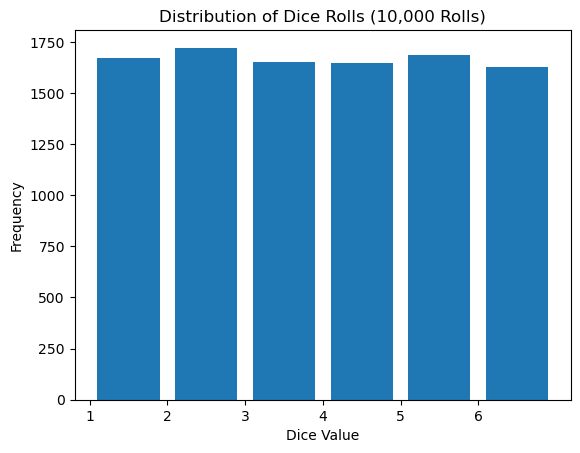

In [10]:
rolls = [random.randint(1, 6) for _ in range(10000)]

plt.hist(rolls, bins=[1,2,3,4,5,6,7], rwidth=0.8)
plt.title("Distribution of Dice Rolls (10,000 Rolls)")
plt.xlabel("Dice Value")
plt.ylabel("Frequency")
plt.xticks([1,2,3,4,5,6])
plt.show()

## Counting Matching Dice

To get a Yahtzee, all five dice must match.

This function finds the largest number of matching dice in a roll. It helps determine how close I am to achieving a Yahtzee.

In [11]:
def count_max_match(dice):
    counts = {}
    for d in dice:
        counts[d] = counts.get(d, 0) + 1
    return max(counts.values())

## Starting Roll Strength

Not all first rolls are equal.

This chart shows how often I start with:
- All different numbers  
- A pair  
- Three of a kind, etc.  

This helps explain why some turns are easier than others.

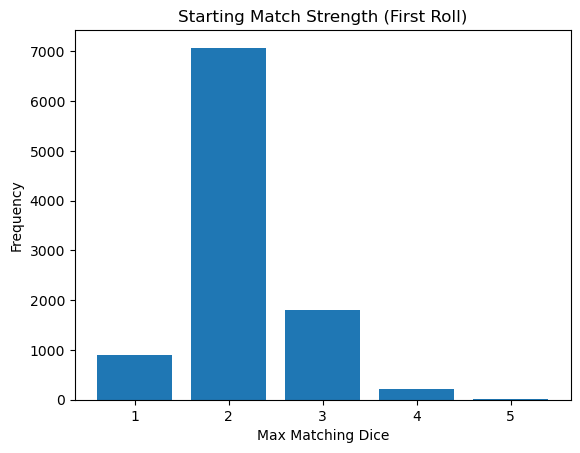

In [12]:
starting_matches = []

for _ in range(10000):
    dice = roll_dice(5)
    starting_matches.append(count_max_match(dice))

counts = Counter(starting_matches)

x = sorted(counts.keys())
y = [counts[val] for val in x]

plt.bar(x, y)
plt.title("Starting Match Strength (First Roll)")
plt.xlabel("Max Matching Dice")
plt.ylabel("Frequency")
plt.xticks([1,2,3,4,5])
plt.show()

## Simulating a Full Yahtzee Turn

A Yahtzee turn allows up to three rolls.

Strategy used in this simulation:
- After each roll, keep the number that appears most often  
- Re-roll the remaining dice  
- Repeat for up to three rolls  

This approximates how a player would realistically try to achieve a Yahtzee.

In [13]:
def simulate_turn():
    # Roll 1
    dice = roll_dice(5)
    
    target = max(set(dice), key=dice.count)
    kept = [d for d in dice if d == target]
    
    # Roll 2
    dice = kept + roll_dice(5 - len(kept))
    target = max(set(dice), key=dice.count)
    kept = [d for d in dice if d == target]
    
    # Roll 3
    dice = kept + roll_dice(5 - len(kept))
    
    return 1 if count_max_match(dice) == 5 else 0

## Running the Simulation

To estimate probability, I simulate thousands of Yahtzee turns.

Each simulation represents one full turn (up to three rolls).

In [14]:
def run_simulation(trials=100000):
    return [simulate_turn() for _ in range(trials)]

results = run_simulation(100000)

## Simulation Outcomes

This chart shows how often I successfully get a Yahtzee versus how often I fail.

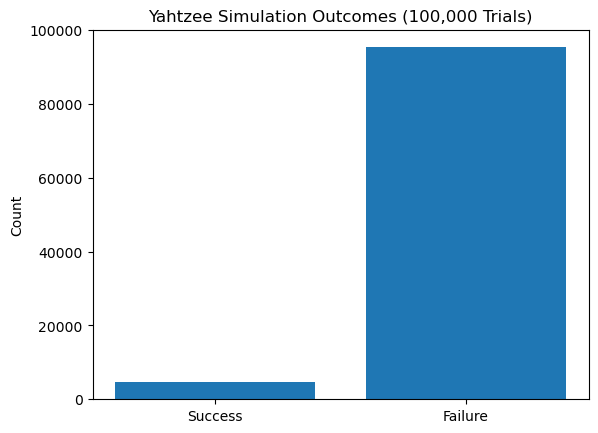

In [15]:
success = sum(results)
failure = len(results) - success

plt.bar(["Success", "Failure"], [success, failure])
plt.title("Yahtzee Simulation Outcomes (100,000 Trials)")
plt.ylabel("Count")
plt.show()

## Calculating Probability

Now I calculate the overall probability of achieving a Yahtzee.

This represents the percentage of simulated turns that resulted in success.

In [16]:
probability = np.mean(results)
print(f"Estimated Probability: {probability:.4f}")

Estimated Probability: 0.0460


## Convergence of the Simulation

This chart shows how the estimated probability stabilizes as more simulations are run.

At the beginning, results fluctuate. Over time, the estimate becomes more stable and reliable.

This is a key concept in Monte Carlo Simulation.

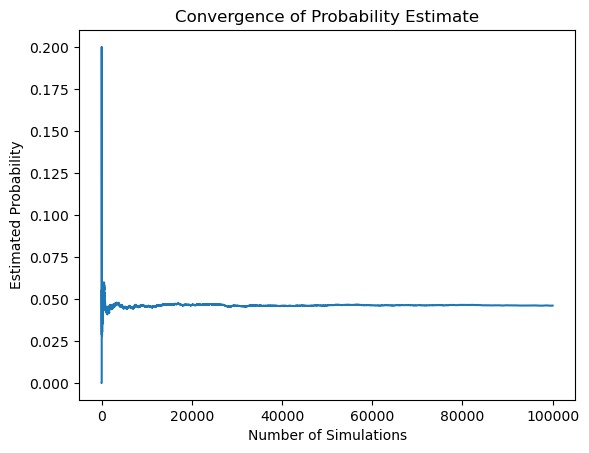

In [17]:
cumulative_avg = np.cumsum(results) / np.arange(1, len(results)+1)

plt.plot(cumulative_avg)
plt.title("Convergence of Probability Estimate")
plt.xlabel("Number of Simulations")
plt.ylabel("Estimated Probability")
plt.show()

## Probability by Starting Strength

This chart shows how the probability of success changes depending on how strong the first roll is.

For example:
- Starting with three of a kind gives a much higher chance than starting with all different numbers.

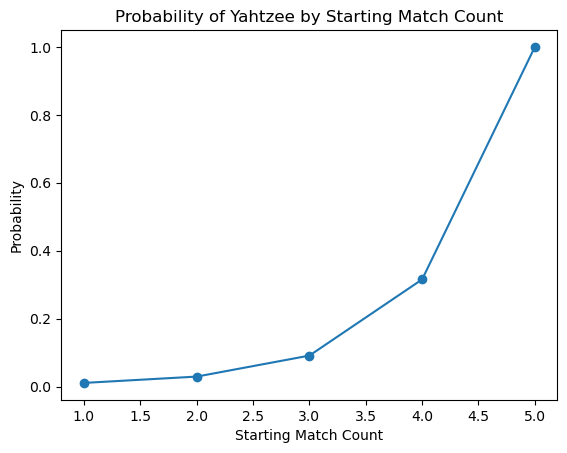

In [18]:
from collections import defaultdict

results_by_start = defaultdict(list)

for _ in range(100000):
    dice = roll_dice(5)
    start = count_max_match(dice)
    
    target = max(set(dice), key=dice.count)
    kept = [d for d in dice if d == target]
    
    dice = kept + roll_dice(5 - len(kept))
    target = max(set(dice), key=dice.count)
    kept = [d for d in dice if d == target]
    
    dice = kept + roll_dice(5 - len(kept))
    
    success = 1 if count_max_match(dice) == 5 else 0
    results_by_start[start].append(success)

x = sorted(results_by_start.keys())
y = [np.mean(results_by_start[k]) for k in x]

plt.plot(x, y, marker='o')
plt.title("Probability of Yahtzee by Starting Match Count")
plt.xlabel("Starting Match Count")
plt.ylabel("Probability")
plt.show()

## Interpretation of Results

From this simulation:

- The probability of getting a Yahtzee in one turn is about **4.5%**
- The convergence chart shows the estimate stabilizing over time
- The starting match chart explains why most attempts fail early

This demonstrates how repeated random simulations can produce reliable probability estimates.

## Why This Matters

This project demonstrates how randomness can be analyzed using data.

Even though Yahtzee is a game of chance, techniques like Monte Carlo Simulation allow us to:

- Estimate probabilities  
- Evaluate strategies  
- Make informed decisions under uncertainty  

These same concepts are widely used in business for forecasting, risk analysis, and decision-making.